In [113]:
import torch
from torchvision import datasets, transforms
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, random_split

import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
from IPython.display import clear_output

#### нормализую данные, нашел в сети вычисленные значения среднего и стандарного отклонения, чтобы не проходиться по всей дате и не считать, нормализация поможет нам избежать взрывов и затуханий градиентов, что поспособствует скорейшему схождению моделек

In [51]:
mean_std = ((0.1307,), (0.3081,))
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*mean_std)
])

mnist_train = datasets.MNIST(
    root='mnist',
    download=True,
    train=True,
    transform=transform
)

mnist_test = datasets.MNIST(
    root='mnist',
    download=True,
    train=False,
    transform=transform
)

#### добавляем Valid выборку, для вывода всех лосов в дальнейшем

In [52]:
mnist_train, mnist_val = random_split(mnist_train, [50000, 10000])

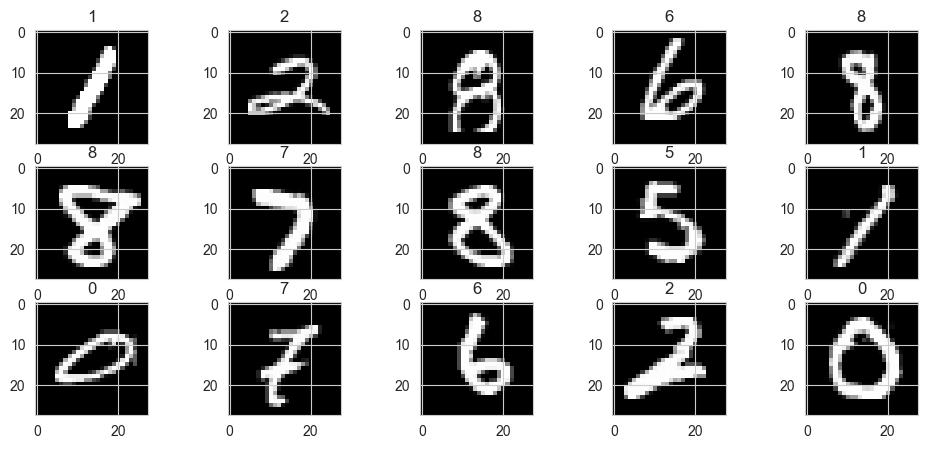

In [53]:
plt.figure(figsize=(12,5))

for i in range(15):
    X, y = mnist_train[i]
    plt.subplot(3,5, i + 1)
    plt.title(f'{y}')
    plt.imshow(X.squeeze(), cmap='gray')

plt.show()

#### Модели: рассмотрю 3 аритектуры + 3 этих же архитектуры, но с BatchNorm, DropOut
#### и того 6 моделей !!!

In [56]:
### 1
model_easy = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=784, out_features=128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

### 2
model_easy_BNDO = nn.Sequential(
    nn.Flatten(),

    nn.Linear(in_features=784, out_features=128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(in_features=128, out_features=10)
)

### 3
model_medium = nn.Sequential(
    nn.Flatten(),

    nn.Linear(in_features=784, out_features=512),
    nn.ReLU(),

    nn.Linear(in_features=512, out_features=256),
    nn.ReLU(),

    nn.Linear(in_features=256, out_features=10)
)

### 4
model_medium_BNDO = nn.Sequential(
    nn.Flatten(),

    nn.Linear(in_features=784, out_features=512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(in_features=512, out_features=256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(in_features=256, out_features=10)
)

### 5
model_hard = nn.Sequential(
    nn.Flatten(),

    nn.Linear(in_features=784, out_features=1024),
    nn.ReLU(),

    nn.Linear(in_features=1024, out_features=512),
    nn.ReLU(),

    nn.Linear(in_features=512, out_features=256),
    nn.ReLU(),

    nn.Linear(in_features=256, out_features=128),
    nn.ReLU(),

    nn.Linear(in_features=128, out_features=10)
)

### 6
model_hard_BNDO = nn.Sequential(
    nn.Flatten(),

    nn.Linear(in_features=784, out_features=1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(in_features=1024, out_features=512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(in_features=512, out_features=256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(in_features=256, out_features=128),
    nn.BatchNorm1d(128),
    nn.ReLU(),

    nn.Linear(in_features=128, out_features=10)
)

#### простая проверка, что все работает, предсказание естественно плохое, т.к обучения еще не было

In [57]:
with torch.no_grad():
    x, y = mnist_train[9]
    print(f'y = {y}')
    print(f'y^ = {model_easy(x).argmax(dim=1).item()}')
    print(f'probability: {model_easy(x).max()}')

y = 1
y^ = 6
probability: 0.4171675443649292


#### Loss - многоклассовая энтропия

In [59]:
loss = nn.CrossEntropyLoss()

#### Оптимизатор - SGD (пусть будет именно он, не буду брать Adam, который более умный, хочу увидеть в дальнейшем более отличные друг друга графики loss

In [60]:
SGD_easy = optim.SGD(model_easy.parameters(), lr=1e-1)
SGD_easy_BNDO = optim.SGD(model_easy_BNDO.parameters(), lr=1e-1)

SGD_medium = optim.SGD(model_medium.parameters(), lr=1e-1)
SGD_medium_BNDO = optim.SGD(model_medium_BNDO.parameters(), lr=1e-1)

SGD_hard = optim.SGD(model_hard.parameters(), lr=1e-1)
SGD_hard_BNDO = optim.SGD(model_hard_BNDO.parameters(), lr=1e-1)

#### функция обучения и подсчета loss

In [61]:
def run_func(model, dataloader, loss_function, optimizer=None):
    if optimizer == None:
        model.eval()
    else:
        model.train()

    total_loss = 0

    for X, y in dataloader:
        pred = model(X)
        loss = loss_function(pred, y)
        total_loss += loss.item()

        if optimizer != None:
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    return total_loss / len(dataloader)

#### Визуализалка loss

In [37]:
def show_loss(train_loss, val_loss):
    clear_output()

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.title('Train Loss')
    plt.plot(np.arange(len(train_loss)), train_loss)
    plt.yscale('log')
    plt.grid()

    plt.subplot(1,2,2)
    plt.title('Val Loss')
    plt.plot(np.arange(len(val_loss)), val_loss)
    plt.yscale('log')
    plt.grid()

    plt.show()

#### батчи, эпохи, лоадеры

In [62]:
BATCH_SIZE = 128
NUM_EPOCHS = 15

train_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(mnist_val, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=BATCH_SIZE, shuffle=False)

#### функция которая объединит работу предыдущих

In [63]:
def learn_progress(model_v, optimizer_):
    train_loss_list = list()
    val_loss_list = list()

    for ep in range(NUM_EPOCHS):
        train_loss = run_func(model_v, train_loader, loss, optimizer_)
        train_loss_list.append(train_loss)

        val_loss = run_func(model_v, valid_loader, loss)
        val_loss_list.append(val_loss)

        if ep % 10 == 9:
            show_loss(train_loss_list, val_loss_list)

    return val_loss_list

#### easy

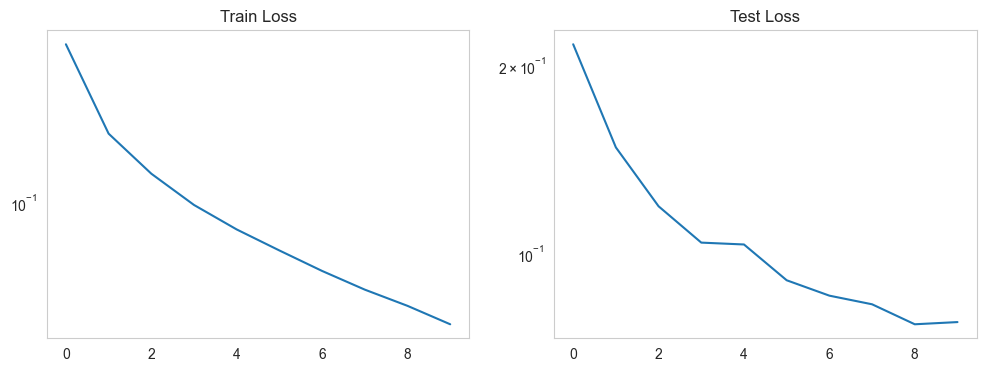

In [64]:
loss_easy = learn_progress(model_easy, SGD_easy)

#### easy + BatchNorm + DropOut

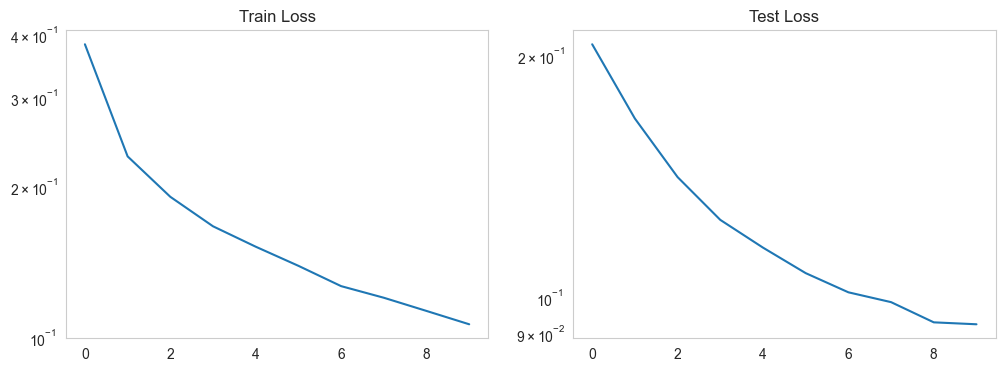

In [65]:
loss_easy_BNDO = learn_progress(model_easy_BNDO, SGD_easy_BNDO)

#### medium

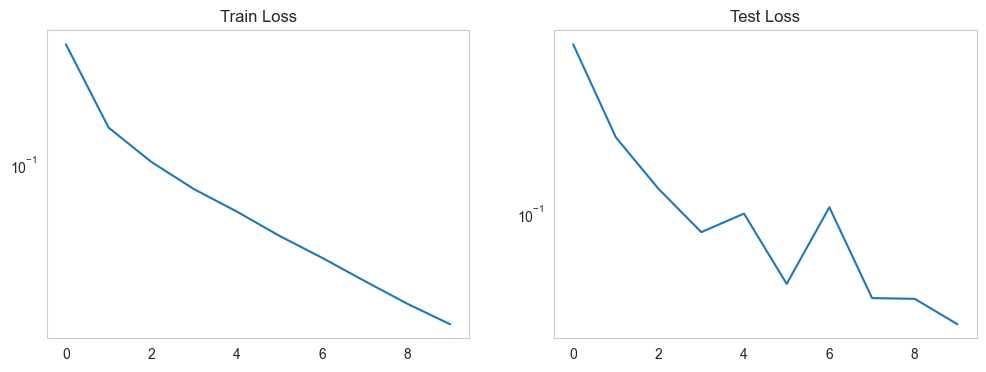

In [66]:
loss_medium = learn_progress(model_medium, SGD_medium)

#### medium + BatchNorm + DropOut

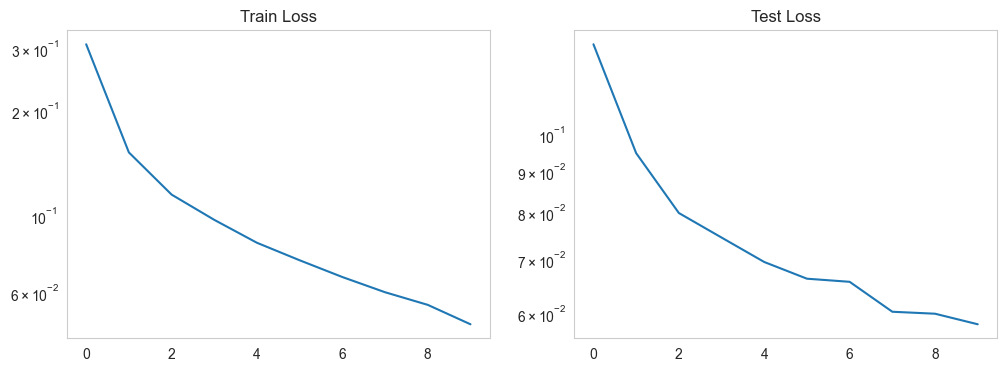

In [67]:
loss_medium_BNDO = learn_progress(model_medium_BNDO, SGD_medium_BNDO)

#### hard

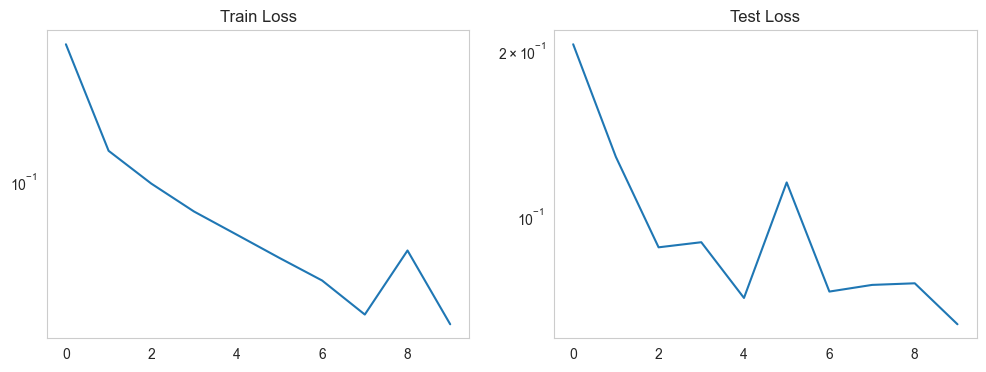

In [68]:
loss_hard = learn_progress(model_hard, SGD_hard)

#### hard + BatchNorm + DropOut

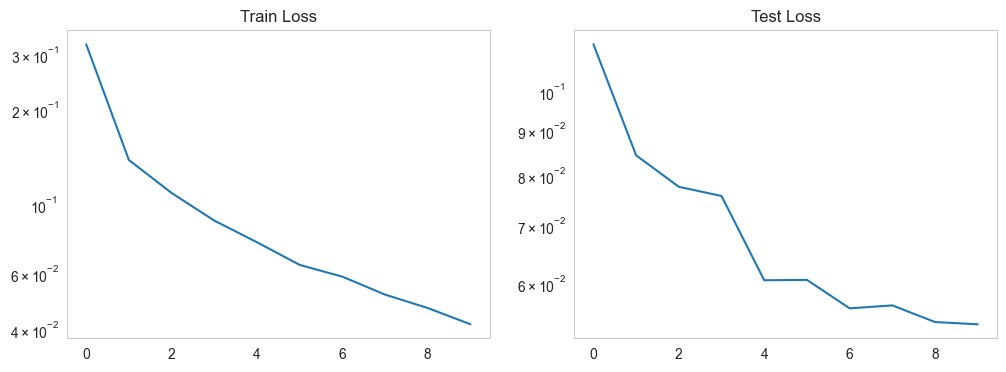

In [69]:
loss_hard_BNDO = learn_progress(model_hard_BNDO, SGD_hard_BNDO)

#### все валидационные loss

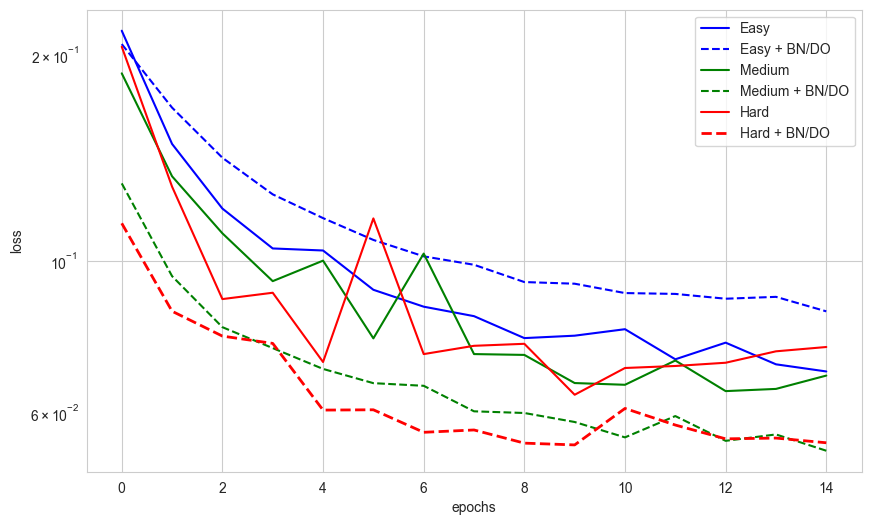

In [82]:
plt.figure(figsize=(10, 6))

plt.plot(loss_easy, label='Easy', c='blue')
plt.plot(loss_easy_BNDO, label='Easy + BN/DO', linestyle='--', c='blue')

plt.plot(loss_medium, label='Medium', c='green')
plt.plot(loss_medium_BNDO, label='Medium + BN/DO', linestyle='--', c='green')

plt.plot(loss_hard, label='Hard', c='red')
plt.plot(loss_hard_BNDO, label='Hard + BN/DO', linestyle='--', linewidth=2, c='red')

plt.yscale('log')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

#### считалка параметров

In [127]:
def params_model(model):
    count_params = 0
    for params in model.parameters():
        count_params += torch.numel(params)
    return count_params

#### получаем предсказания на test

In [125]:
def target_pred(model, loader=test_loader):
    target, pred = list(), list()

    model.eval()
    for x, y in loader:
        outputs = model(x)
        pred.extend(outputs.argmax(1).tolist())
        target.extend(y.tolist())

    return target, pred

#### summary таблица со всеми результатами

In [126]:
table = {
    'parameters': {
        'easy': params_model(model_easy),
        'BNDO + easy': params_model(model_easy_BNDO),
        'medium': params_model(model_medium),
        'BNDO + medium': params_model(model_medium_BNDO),
        'hard': params_model(model_hard),
        'BNDO + hard': params_model(model_hard_BNDO),
    },
    'Validation min Loss': {
        'easy': min(loss_easy),
        'BNDO + easy': min(loss_easy_BNDO),
        'medium': min(loss_medium),
        'BNDO + medium': min(loss_medium_BNDO),
        'hard': min(loss_hard),
        'BNDO + hard': min(loss_hard_BNDO),
    },
    'accuracy': {
        'easy': accuracy_score(*target_pred(model_easy)),
        'BNDO + easy': accuracy_score(*target_pred(model_easy_BNDO)),
        'medium': accuracy_score(*target_pred(model_medium)),
        'BNDO + medium': accuracy_score(*target_pred(model_medium_BNDO)),
        'hard': accuracy_score(*target_pred(model_hard)),
        'BNDO + hard': accuracy_score(*target_pred(model_hard_BNDO)),
    },
    'precision': {
        'easy': precision_score(*target_pred(model_easy), average='macro'),
        'BNDO + easy': precision_score(*target_pred(model_easy_BNDO), average='macro'),
        'medium': precision_score(*target_pred(model_medium), average='macro'),
        'BNDO + medium': precision_score(*target_pred(model_medium_BNDO), average='macro'),
        'hard': precision_score(*target_pred(model_hard), average='macro'),
        'BNDO + hard': precision_score(*target_pred(model_hard_BNDO), average='macro'),
    },
    'recall': {
        'easy': recall_score(*target_pred(model_easy), average='macro'),
        'BNDO + easy': recall_score(*target_pred(model_easy_BNDO), average='macro'),
        'medium': recall_score(*target_pred(model_medium), average='macro'),
        'BNDO + medium': recall_score(*target_pred(model_medium_BNDO), average='macro'),
        'hard': recall_score(*target_pred(model_hard), average='macro'),
        'BNDO + hard': recall_score(*target_pred(model_hard_BNDO), average='macro'),
    },
    'f1-score': {
        'easy': f1_score(*target_pred(model_easy), average='macro'),
        'BNDO + easy': f1_score(*target_pred(model_easy_BNDO), average='macro'),
        'medium': f1_score(*target_pred(model_medium), average='macro'),
        'BNDO + medium': f1_score(*target_pred(model_medium_BNDO), average='macro'),
        'hard': f1_score(*target_pred(model_hard), average='macro'),
        'BNDO + hard': f1_score(*target_pred(model_hard_BNDO), average='macro'),
    },
}

summary_table = pd.DataFrame(table)
summary_table = summary_table.reset_index()
summary_table = summary_table.rename(columns={'index': 'Name'})
summary_table.index = summary_table.index + 1

summary_table

,Name,parameters,Validation min Loss,accuracy,precision,recall,f1-score
1,easy,101770,0.068944,0.9799,0.979842,0.979720,0.979776
2,BNDO + easy,102026,0.084367,0.9742,0.974045,0.974039,0.974025
3,medium,535818,0.064542,0.9804,0.980328,0.980313,0.980302
4,BNDO + medium,537354,0.052833,0.9833,0.983297,0.983165,0.983220
5,hard,1494154,0.063758,0.9827,0.982641,0.982561,0.982594
6,BNDO + hard,1497994,0.053874,0.9844,0.984376,0.984334,0.984345


#### Вывод: с ростом параметров от самой простой сетки до самой сложной по архитектуре, точность несомненно растет, это видно по всем метрикам, значит более глубокие и широкие сетки могут улавливать более сложные признаки из фоток.

#### Что по поводу DropOut и BatchNorm? - они тоже помогли, добавление в моделях MEDIUM и HARD заметно снизило Validation min Loss. Значит гипотеза о схождении подтверждается, обучение стало более качественным, но заметим аномалию в модели EASY, там применение регуляризации ухудшило loss! Это говорит о том, что для простых сеток(где мало параметров) применение DO и BN может быть избыточным, оно помешает модельке выучить какие-то базовые закономерности.

#### по итогу, самые крутые результаты показала HARD + DropOut + BatchNorm, но в силу ее сложности я наверное выбрал бы модель MEDIUM + DropOut + BatchNorm, так как параметров в ней почти в 3 раза меньше(ниже нагрузка на систему), а резульаты метрик качества отличаются в среднем на 0.001.

<img src="https://i.pinimg.com/236x/99/fc/68/99fc68e4107aab1774714b49255ced4f.jpg" width="250">